# Workflow
This notebook illustrates the **madis-data** workflow. It performs the following tasks:

* download MESONET surface observations data files for January 2026 from the [MADIS archive](https://madis-data.ncep.noaa.gov/madisPublic1/data/archive/),
* extract data for stations in the state of Colorado of the following variables:
    - 2 m temperature,
    - 2 m dewpoint temperature,
    - 10 m west-east and south-north wind speed,
    - solar radiation,
* interpolate them to full-hourly time series,
* plot the original and the interpolated time series at an individual station over select time intervals,
* count the number of stations that have valid data for at least a given fraction of the time,
* plot the stations in the state of Colorado on a US map.

Downloading the data files from the [MADIS archive](https://madis-data.ncep.noaa.gov/madisPublic1/data/archive/) takes approximately 1 hour and requires approximately 30 GB disk space. Once the data files have been downloaded, the rest of the script runs in under a few minutes on a machine with 8 cores. Progress is reported by the data download step and by each computationally expensive step.

This notebook requires the Jupyter kernel madis-data, which is automaticaly installed as part of the madis-data conda development environment. The  conda development environment can be installed from the root directory of the **madis-data** distribution with

    make setup-dev-env

In [1]:
# Automatically reload modules
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import xarray as xr
from matplotlib import pyplot as plt

import pandas as pd
import geopandas as gpd

import h5netcdf

In [3]:
from madis_data.mesonet import download_mesonet, plot_locations_conus, extract_station_data, interpolate_to_full_hour, merge_hourly
from madis_data.xarray_tools import get_missing_value, mask_with_missing_value
from madis_data.mesonet_region_filter import filter_by_region

## Settings

In [4]:
start_date = datetime(2025,12,31,0,0,0)
end_date = datetime(2026,1,31,23,0,0)

In [5]:
data_dir = Path('../data')

In [6]:
file_tag = str(start_date).replace(' ','_') + '-' + str(end_date).replace(' ','_')

## Download and pre-process MADIS Mesonet data

For some dates and times, no data files are available on the server, and the following will issue corresponding warnings.

In [7]:
datetime.now()

datetime.datetime(2026, 8, 4, 11, 41, 6, 304881)

In [8]:
mm_files = download_mesonet(start_date, end_date, data_dir, n_jobs = 24, preprocess = True, refresh = False)

Progress: 100.00 %


In [9]:
datetime.now()

datetime.datetime(2026, 8, 4, 12, 27, 58, 144415)

## Isolate data for stations in Colorado

In [10]:
datetime.now()

datetime.datetime(2026, 8, 4, 12, 27, 58, 155310)

In [11]:
region_name = 'CO'

In [12]:
ds_region = filter_by_region(mm_files, region_name, n_jobs= 24)

ERROR 1: PROJ: proj_create_from_database: Open of /home/jkazil/Software/miniforge3/envs/madis-data/share/proj failed
Scanning station metadata: 100%|██████████| 768/768 files [00:59<00:00, 13.01files/s]
Extracting regional records: 100%|██████████| 768/768 files [00:18<00:00, 42.62files/s]


Save the data for the region as a netCDF file

In [13]:
region_out_file_name = region_name + '.' + file_tag  + '.nc'

In [14]:
region_out_file = data_dir / Path(region_out_file_name)

In [15]:
ds_region.to_netcdf(region_out_file)

## Plot stations in the region on a map

In [16]:
plot_file_name = region_name + '.' + file_tag  + '_stations.png'
plot_file = data_dir / plot_file_name

plot_file = plot_locations_conus(
    list(ds_region['stationID'].values),
    list(ds_region['latitude'].values),
    list(ds_region['longitude'].values),
    plot_file)

In [17]:
datetime.now()

datetime.datetime(2026, 8, 4, 12, 29, 17, 695140)

## Isolate time series for each station in the region

In [18]:
datetime.now()

datetime.datetime(2026, 8, 4, 12, 29, 17, 713797)

In [19]:
station_ids = list(ds_region['stationID'].values)

In [20]:
ds_station_dict = extract_station_data(ds_region,station_ids)

Extracting data by station ...
Completed loading data to memory - moving on to preparation of station identifiers ...
Completed preparation of station identifiers - moving on to selection of data at requested stations ...
Completed selection of data at requested stations - moving on to assembling valid data at requested stations ...
Completed assembling valid data at requested stations - moving on to building datasets for requested stations ...
Completed building datasets for requested stations


In [21]:
datetime.now()

datetime.datetime(2026, 8, 4, 12, 29, 22, 778875)

## Interpolate to full-hourly time series for January 2025

In [22]:
datetime.now()

datetime.datetime(2026, 8, 4, 12, 29, 22, 820072)

In [23]:
start_date_hourly = datetime(2026,1,1,0,0,0)
end_date_hourly = datetime(2026,1,31,23,0,0)

In [24]:
ds_station_hourly_dict = interpolate_to_full_hour(ds_station_dict,start_date=start_date_hourly,end_date=end_date_hourly)

Progress: 100.00 %


In [25]:
ds_hourly = merge_hourly(ds_station_hourly_dict)

Save the full-hourly interpolated data as a netCDF file

In [26]:
file_tag_hourly = str(start_date_hourly).replace(' ','_') + '-' + str(end_date_hourly).replace(' ','_') + '.hourly'

In [27]:
region_out_file_name_hourly = region_name + '.' + file_tag_hourly + '.nc'

In [28]:
ds_hourly.to_netcdf(data_dir / Path(region_out_file_name_hourly), engine='h5netcdf', mode='w')

Plot the original and the full-hourly interpolated data at the station

In [29]:
ds_hourly = xr.open_dataset(data_dir / Path(region_out_file_name_hourly))

Select a station

In [30]:
station_id = 'AR893'
station_ix = np.flatnonzero(ds_hourly['STATION_NAME'].values == station_id)

Time range to plot

In [31]:
time_min = max(ds_station_dict[station_id]['time'][0],ds_hourly['time'][0])
time_max = min(ds_station_dict[station_id]['time'][-1],ds_hourly['time'][-1])

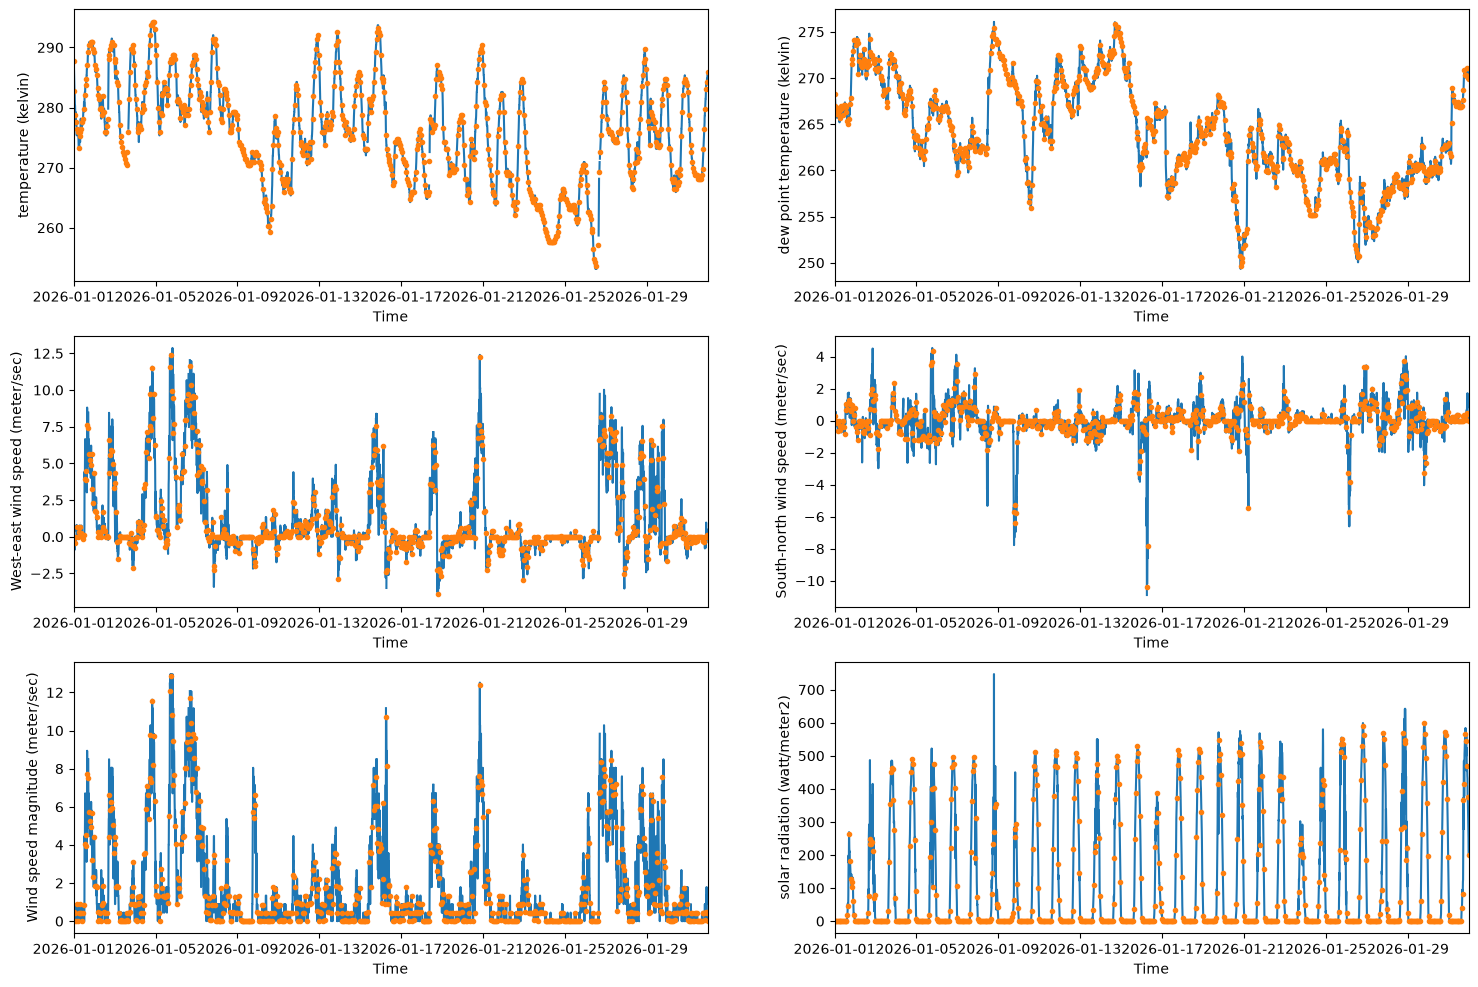

In [32]:
fig, axes = plt.subplots(3,2,figsize=(18,12),squeeze=False)

var_name = 'temperature'
axes[0,0].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[0,0].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[0,0].set_ylabel(ds_station_dict[station_id][var_name].attrs['long_name'] + ' (' + ds_station_dict[station_id][var_name].attrs['units'] + ')')

var_name = 'dewpoint'
axes[0,1].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[0,1].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[0,1].set_ylabel(ds_station_dict[station_id][var_name].attrs['long_name'] + ' (' + ds_station_dict[station_id][var_name].attrs['units'] + ')')

var_name = 'U10'
axes[1,0].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[1,0].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[1,0].set_ylabel(ds_station_dict[station_id][var_name].attrs['long_name'] + ' (' + ds_station_dict[station_id][var_name].attrs['units'] + ')')

var_name = 'V10'
axes[1,1].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[1,1].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[1,1].set_ylabel(ds_station_dict[station_id][var_name].attrs['long_name'] + ' (' + ds_station_dict[station_id][var_name].attrs['units'] + ')')

var_name = 'Wind speed'
axes[2,0].plot(ds_station_dict[station_id]['time'],np.sqrt(ds_station_dict[station_id]['U10'][:]**2+ds_station_dict[station_id]['V10'][:]**2))
axes[2,0].plot(ds_hourly['time'],np.sqrt(ds_hourly['U10'][:,station_ix]**2+ds_hourly['V10'][:,station_ix]**2),marker='.',linewidth=0)
axes[2,0].set_ylabel('Wind speed magnitude' + ' (' + ds_station_dict[station_id]['U10'].attrs['units'] + ')')

var_name = 'solarRadiation'
axes[2,1].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[2,1].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[2,1].set_ylabel(ds_station_dict[station_id][var_name].attrs['long_name'] + ' (' + ds_station_dict[station_id][var_name].attrs['units'] + ')')

for ax in axes.flat:
    ax.set_xlim([time_min,time_max])
    ax.set_xlabel('Time')

In [33]:
datetime.now()

datetime.datetime(2026, 8, 4, 12, 30, 10, 873270)

In [34]:
ds_region_2025 = xr.open_dataset(region_out_file)

In [35]:
station_ids_2025 = list(ds_region_2025['stationID'].values)

In [36]:
ds_station_dict_2025 = extract_station_data(ds_region_2025,station_ids_2025)

Extracting data by station ...
Completed loading data to memory - moving on to preparation of station identifiers ...
Completed preparation of station identifiers - moving on to selection of data at requested stations ...
Completed selection of data at requested stations - moving on to assembling valid data at requested stations ...
Completed assembling valid data at requested stations - moving on to building datasets for requested stations ...
Completed building datasets for requested stations


In [37]:
start_date_hourly = datetime(2025,1,1,0,0,0)
end_date_hourly = datetime(2025,12,31,23,0,0)

In [38]:
ds_2025_station_hourly_dict = interpolate_to_full_hour(ds_station_dict_2025,start_date=start_date_hourly,end_date=end_date_hourly)

Progress: 100.00 %


In [39]:
ds_hourly_2025 = merge_hourly(ds_2025_station_hourly_dict)

In [40]:
file_tag_hourly = str(start_date_hourly).replace(' ','_') + '-' + str(end_date_hourly).replace(' ','_') + '.hourly'

In [41]:
region_out_file_name_hourly = region_name + '.' + file_tag_hourly + '.nc'

In [42]:
ds_hourly_2025.to_netcdf(data_dir / Path(region_out_file_name_hourly), engine='h5netcdf', mode='w')

Plot the original and the full-hourly interpolated data at the station

In [43]:
ds_hourly = xr.open_dataset(data_dir / Path(region_out_file_name_hourly))

Select a station

In [44]:
station_id = 'AR893'
station_ix = np.flatnonzero(ds_hourly['STATION_NAME'].values == station_id)

Time range to plot

In [45]:
#time_min = max(ds_station_dict[station_id]['time'][0],ds_hourly['time'][0])
#time_max = min(ds_station_dict[station_id]['time'][-1],ds_hourly['time'][-1])

time_min = datetime(2025,1,16)
time_max = datetime(2025,1,18)

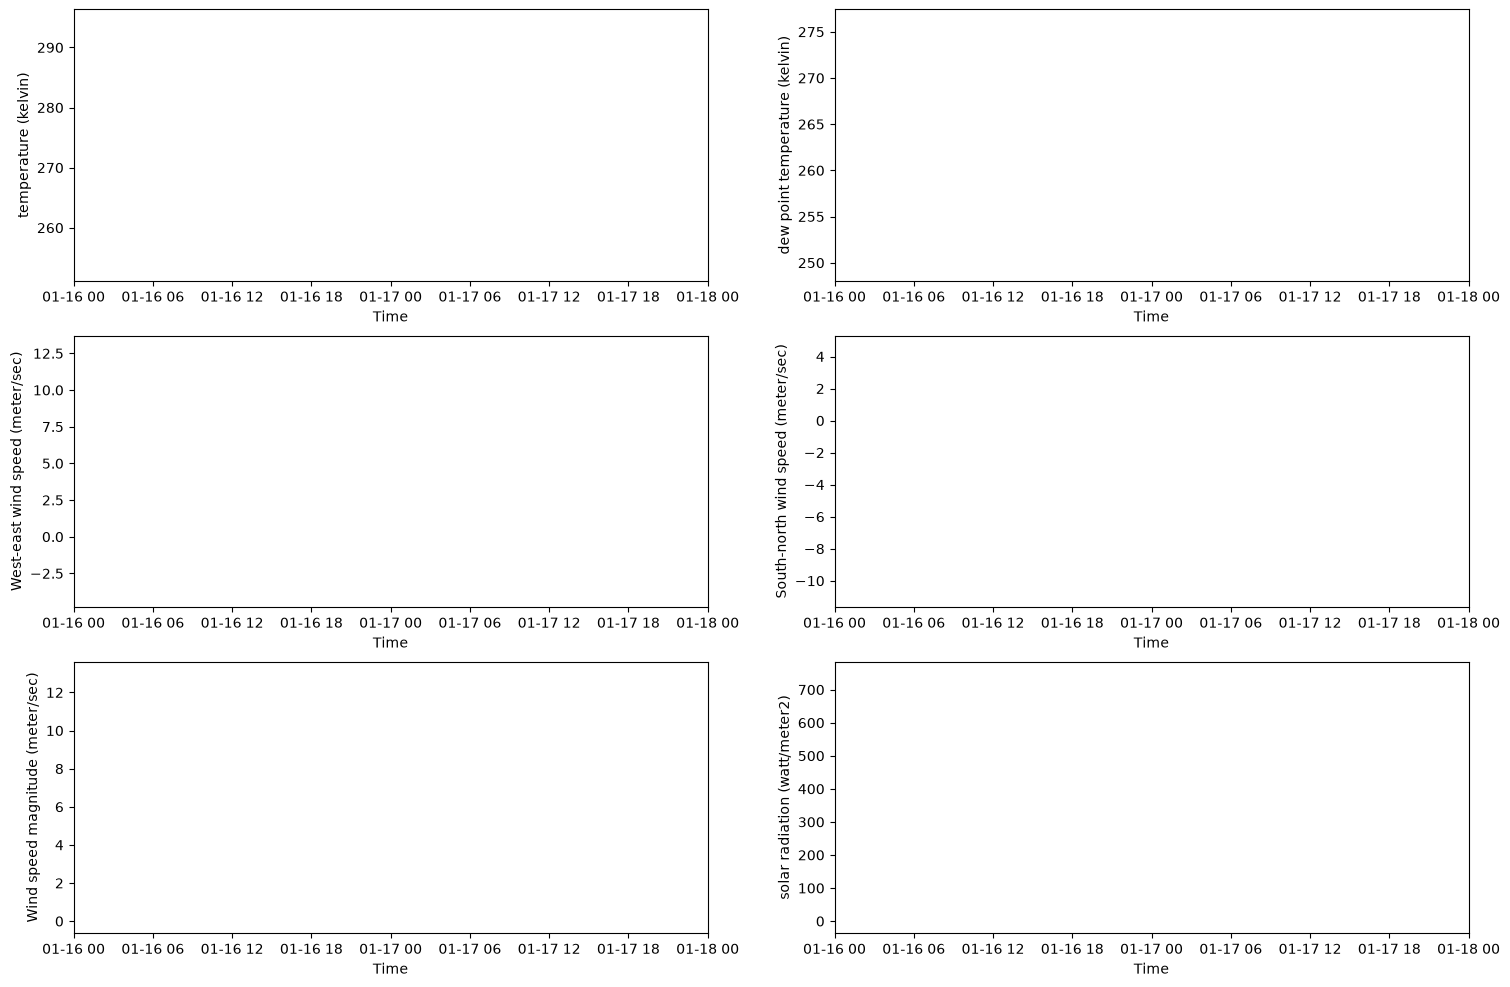

In [46]:
fig, axes = plt.subplots(3,2,figsize=(18,12),squeeze=False)

var_name = 'temperature'
axes[0,0].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[0,0].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[0,0].set_ylabel(ds_station_dict[station_id][var_name].attrs['long_name'] + ' (' + ds_station_dict[station_id][var_name].attrs['units'] + ')')

var_name = 'dewpoint'
axes[0,1].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[0,1].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[0,1].set_ylabel(ds_station_dict[station_id][var_name].attrs['long_name'] + ' (' + ds_station_dict[station_id][var_name].attrs['units'] + ')')

var_name = 'U10'
axes[1,0].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[1,0].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[1,0].set_ylabel(ds_station_dict[station_id][var_name].attrs['long_name'] + ' (' + ds_station_dict[station_id][var_name].attrs['units'] + ')')

var_name = 'V10'
axes[1,1].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[1,1].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[1,1].set_ylabel(ds_station_dict[station_id][var_name].attrs['long_name'] + ' (' + ds_station_dict[station_id][var_name].attrs['units'] + ')')

var_name = 'Wind speed'
axes[2,0].plot(ds_station_dict[station_id]['time'],np.sqrt(ds_station_dict[station_id]['U10'][:]**2+ds_station_dict[station_id]['V10'][:]**2))
axes[2,0].plot(ds_hourly['time'],np.sqrt(ds_hourly['U10'][:,station_ix]**2+ds_hourly['V10'][:,station_ix]**2),marker='.',linewidth=0)
axes[2,0].set_ylabel('Wind speed magnitude' + ' (' + ds_station_dict[station_id]['U10'].attrs['units'] + ')')

var_name = 'solarRadiation'
axes[2,1].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[2,1].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[2,1].set_ylabel(ds_station_dict[station_id][var_name].attrs['long_name'] + ' (' + ds_station_dict[station_id][var_name].attrs['units'] + ')')

for ax in axes.flat:
    ax.set_xlim([time_min,time_max])
    ax.set_xlabel('Time')

(This should be vectorized)

In [47]:
valid_fraction_threshold = 0.75

min_time = ds_hourly['time'][0].values
max_time = ds_hourly['time'][-1].values

print()
print(min_time,'to',max_time,':')
print()

var_names = ['temperature','dewpoint','U10','V10','solarRadiation']
for var_name in var_names:
    valid_station_n = 0
    for station_id in ds_hourly['STATION_NAME'].values:
        station_ix = np.flatnonzero(ds_hourly['STATION_NAME'].values == station_id)
        valid_fraction = np.isfinite(ds_hourly[var_name][:,station_ix]).mean().values
        if valid_fraction >= valid_fraction_threshold:
            valid_station_n += 1
    print(f'{var_name}: number of stations with a fraction >= {valid_fraction_threshold} of valid hourly data:',valid_station_n,'of',ds_hourly.sizes['station'])


2025-01-01T00:00:00.000000000 to 2025-12-31T23:00:00.000000000 :

temperature: number of stations with a fraction >= 0.75 of valid hourly data: 0 of 1259
dewpoint: number of stations with a fraction >= 0.75 of valid hourly data: 0 of 1259
U10: number of stations with a fraction >= 0.75 of valid hourly data: 0 of 1259
V10: number of stations with a fraction >= 0.75 of valid hourly data: 0 of 1259
solarRadiation: number of stations with a fraction >= 0.75 of valid hourly data: 0 of 1259


In [48]:
valid_fraction_threshold = 0.9

min_time = ds_hourly['time'][0].values
max_time = ds_hourly['time'][-1].values

print()
print(min_time,'to',max_time,':')
print()

var_names = ['temperature','dewpoint','U10','V10','solarRadiation']
for var_name in var_names:
    valid_station_n = 0
    for station_id in ds_hourly['STATION_NAME'].values:
        station_ix = np.flatnonzero(ds_hourly['STATION_NAME'].values == station_id)
        valid_fraction = np.isfinite(ds_hourly[var_name][:,station_ix]).mean().values
        if valid_fraction >= valid_fraction_threshold:
            valid_station_n += 1
    print(f'{var_name}: number of stations with a fraction >= {valid_fraction_threshold} of valid hourly data:',valid_station_n,'of',ds_hourly.sizes['station'])


2025-01-01T00:00:00.000000000 to 2025-12-31T23:00:00.000000000 :

temperature: number of stations with a fraction >= 0.9 of valid hourly data: 0 of 1259
dewpoint: number of stations with a fraction >= 0.9 of valid hourly data: 0 of 1259
U10: number of stations with a fraction >= 0.9 of valid hourly data: 0 of 1259
V10: number of stations with a fraction >= 0.9 of valid hourly data: 0 of 1259
solarRadiation: number of stations with a fraction >= 0.9 of valid hourly data: 0 of 1259
